<a href="https://colab.research.google.com/github/richiehutomoo/PORTFOLIO/blob/main/Profiling_Preparation_%26_Pre_Processing_IMDb_Worst_Movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Note: Unduh dataset Indonesia Reading Interest https://www.kaggle.com/datasets/imaditia/indonesia-reading-interest-2020-2023?resource=download dan unggah melalui menu unggah file di samping. Anda juga bisa mengunggahnya pada Google Drive untuk di-mount

In [6]:
# Install the library
!pip install ydata-profiling

In [7]:
# 1. Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Ensure plots display inline in Colab
%matplotlib inline

In [8]:
# 2. Read the dataset
# The dataset appears to be a comma-separated value file.
try:
    df = pd.read_csv("/movie_data.csv", sep=",")
    print("Dataset read successfully with comma separator.")

    # Print detected column names
    print("=== Detected Columns ===")
    print(df.columns.tolist(), "\n")

except FileNotFoundError:
    print("Error: The file '/movie_data.csv' was not found. Please check the path.")
    df = None # Set df to None if file not found
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")
    df = None # Set df to None if reading fails

Dataset read successfully with comma separator.
=== Detected Columns ===
['name', 'year', 'duration', 'genre', 'rating', 'description', 'director', 'stars'] 



In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# 3. Display the first few rows to verify the structure
print("=== First 5 Rows ===")
print(df.head(), "\n")

=== First 5 Rows ===
                           name  year  duration                       genre  \
0             Daniel the Wizard  2004  1h 21min        Comedy Crime Fantasy   
1                      Smolensk  2016        2h              Drama Thriller   
2                    Foodfight!  2012  1h 31min  Animation Action Adventure   
3              Saving Christmas  2014  1h 19min               Comedy Family   
4  Superbabies: Baby Geniuses 2  2004  1h 28min        Comedy Family Sci-Fi   

   rating                                        description  \
0     1.2  Evil assassins want to kill Daniel Kublbock, t...   
1     1.2  An inspired story of people affected by the 20...   
2     1.3  The evil Brand X joins a supermarket that beco...   
3     1.3  His annual Christmas party faltering thanks to...   
4     1.5  A group of smart-talking toddlers find themsel...   

            director                                             stars  
0        Ulli Lommel  Daniel Küblböck Ulli Lom

In [11]:
# 4. Basic exploration: info, describe, missing values
print("=== DataFrame Info ===")
print(df.info(), "\n")
print("=== Descriptive Statistics ===")
print(df.describe(include='all'), "\n")
print("=== Missing Values Per Column ===")
print(df.isnull().sum(), "\n")

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         250 non-null    object 
 1   year         250 non-null    int64  
 2   duration     250 non-null    object 
 3   genre        250 non-null    object 
 4   rating       250 non-null    float64
 5   description  250 non-null    object 
 6   director     250 non-null    object 
 7   stars        250 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 15.8+ KB
None 

=== Descriptive Statistics ===
                     name         year  duration   genre      rating  \
count                 250   250.000000       250     250  250.000000   
unique                250          NaN        59      99         NaN   
top     Daniel the Wizard          NaN  1h 31min  Comedy         NaN   
freq                    1          NaN        13      14        

In [12]:
# Import necessary libraries : ydata_profiling

from ydata_profiling import ProfileReport


# Generate the profile report
profile = ProfileReport(df, title="Laporan Analisis Kualitas Data REading Interest")

# Display the report in the notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 24.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
# 5. Remove duplicate rows (if any)
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("After removing duplicates, shape:", df.shape, "\n")
else:
    print("No duplicate rows found.\n")

Number of duplicate rows: 0
No duplicate rows found.



In [14]:
# 6. Handle missing values and convert columns that contain commas to proper numeric
# Define the reading interest column
reading_col = "Tingkat Kegemaran Membaca (Reading Interest)"

# List of columns with numeric values stored as strings (with commas)
numeric_cols_with_commas = [
    "Reading Frequency per week",
    "Number of Readings per Quarter",
    "Daily Reading Duration (in minutes)",
    "Internet Access Frequency per Week",
    "Daily Internet Duration (in minutes)",
    reading_col
]

for col in numeric_cols_with_commas:
    if col in df.columns:
        # Replace commas with dots
        df[col] = df[col].astype(str).str.replace(',', '.')
        # Convert to numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill missing with median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Missing values in '{col}' filled with median: {median_val}")

# Convert "Year" to numeric if it exists
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    year_median = df['Year'].median()
    df['Year'] = df['Year'].fillna(year_median)
    print(f"Missing values in 'Year' filled with median: {year_median}")

# Fill missing values in categorical columns with mode
categorical_cols = ["Provinsi", "Category"]
for cat_col in categorical_cols:
    if cat_col in df.columns:
        mode_val = df[cat_col].mode()[0]
        df[cat_col] = df[cat_col].fillna(mode_val)
        print(f"Missing values in '{cat_col}' filled with mode: {mode_val}")
print()

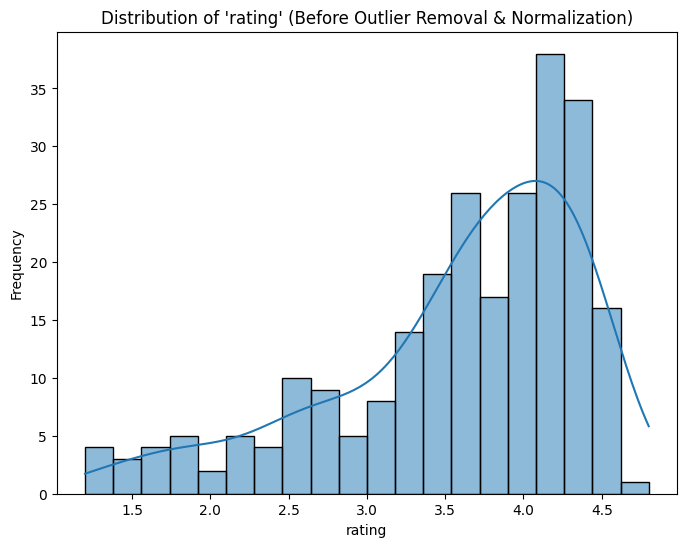

In [17]:
# 7. Visualize the movie rating BEFORE normalization
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title(f"Distribution of 'rating' (Before Outlier Removal & Normalization)")
plt.xlabel('rating')
plt.ylabel("Frequency")
plt.show()

Numeric columns for outlier detection: ['year', 'rating'] 

Initial shape before outlier removal: 250
Column 'year': 5 outliers detected.
Column 'rating': 10 outliers detected.
Shape after outlier removal: (235, 8)

Shape after outlier removal: (235, 8)


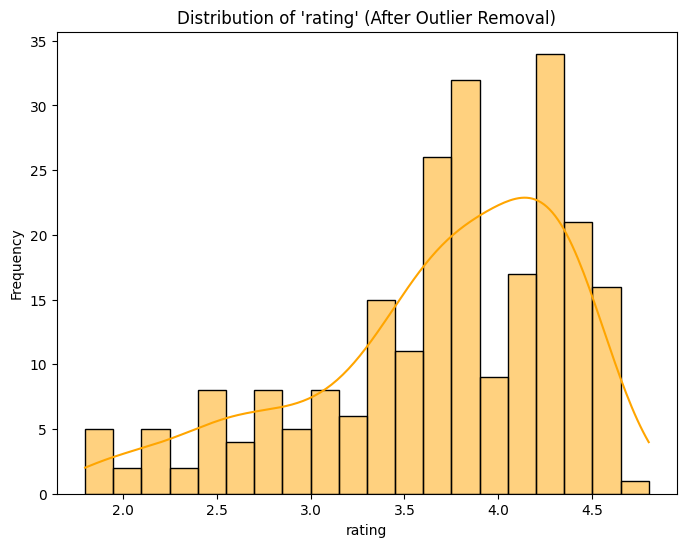

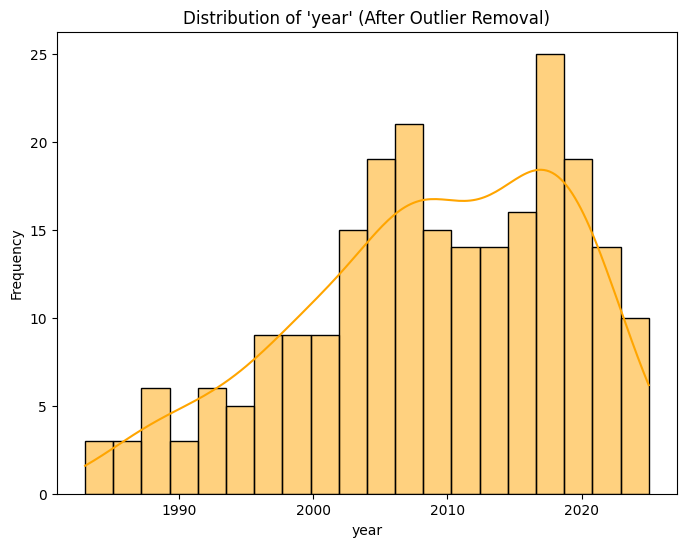

In [18]:
# 8. Detect and remove outliers using the IQR method
def remove_outliers_iqr(data, cols):
    data_clean = data.copy()
    initial_shape = data_clean.shape[0]
    print(f"Initial shape before outlier removal: {initial_shape}")
    for c in cols:
        if c in data_clean.columns:
            Q1 = data_clean[c].quantile(0.25)
            Q3 = data_clean[c].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outlier_indices = data_clean[(data_clean[c] < lower_bound) | (data_clean[c] > upper_bound)].index
            print(f"Column '{c}': {len(outlier_indices)} outliers detected.")
            data_clean = data_clean.drop(index=outlier_indices)
        else:
            print(f"Column '{c}' not found for outlier removal.")
    print(f"Shape after outlier removal: {data_clean.shape}")
    return data_clean

# Identify numeric columns for outlier detection
# Focus on 'year' and 'rating' for outlier detection
numeric_cols_for_outliers = ["year", "rating"]
print("Numeric columns for outlier detection:", numeric_cols_for_outliers, "\n")

if df is not None:
    # Remove outliers from the specified numeric columns
    df_no_outliers = remove_outliers_iqr(df, numeric_cols_for_outliers)
    print("\nShape after outlier removal:", df_no_outliers.shape)

    # Visualize the distribution of relevant numeric columns AFTER outlier removal
    if 'rating' in df_no_outliers.columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(df_no_outliers['rating'], bins=20, kde=True, color='orange')
        plt.title(f"Distribution of 'rating' (After Outlier Removal)")
        plt.xlabel('rating')
        plt.ylabel("Frequency")
        plt.show()
    else:
         print("DataFrame after outlier removal does not have 'rating' column. Cannot visualize.")

    if 'year' in df_no_outliers.columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(df_no_outliers['year'], bins=20, kde=True, color='orange')
        plt.title(f"Distribution of 'year' (After Outlier Removal)")
        plt.xlabel('year')
        plt.ylabel("Frequency")
        plt.show()
    else:
        print("DataFrame after outlier removal does not have 'year' column. Cannot visualize.")

else:
    print("DataFrame not loaded. Cannot perform outlier detection and visualization.")

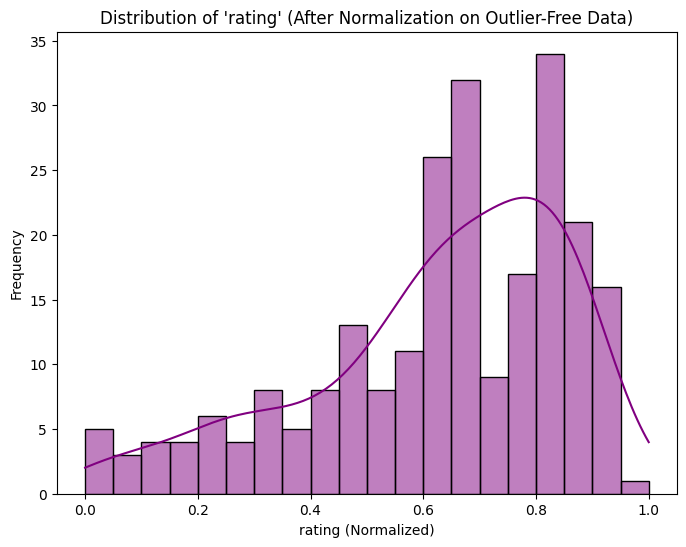

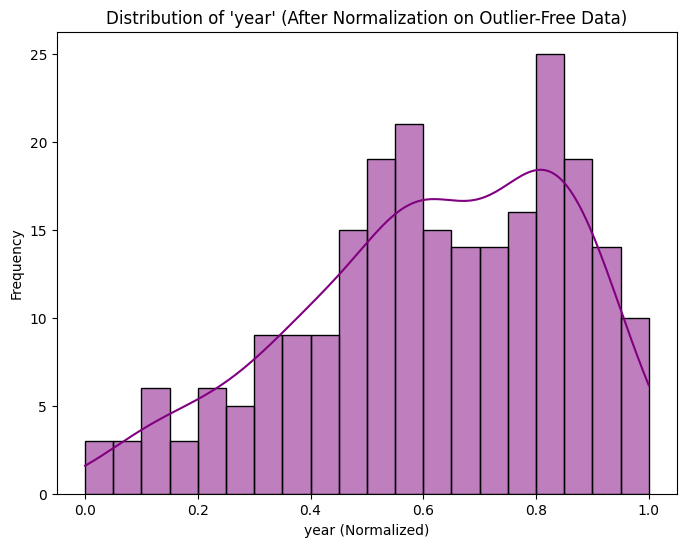


Sample of normalized data (after outlier removal):
                    name      year  duration                 genre    rating  \
11       Going Overboard  0.142857  1h 39min                Comedy  0.000000   
12                 Radhe  0.904762  1h 53min       Action Thriller  0.000000   
13        Disaster Movie  0.595238  1h 27min         Comedy Sci-Fi  0.033333   
14  From Justin to Kelly  0.476190  1h 21min  Comedy Music Musical  0.033333   
15                Race 3  0.833333  2h 40min       Action Thriller  0.033333   

                                          description         director  \
11  A struggling young comedian takes a menial job...  Valerie Breiman   
12  An honest cop is determined to bring down a co...      Prabhu Deva   
13  Over the course of one evening, an unsuspectin...  Jason Friedberg   
14  A waitress from Texas and a college student fr...    Robert Iscove   
15  Relationships and loyalties of a criminal fami...     Remo D'Souza   

                      

In [19]:
# 9. Normalize the data AFTER outlier removal using MinMaxScaler
if 'df_no_outliers' in locals() and df_no_outliers is not None:
    df_no_outliers_normalized = df_no_outliers.copy()
    scaler = MinMaxScaler()
    # Re-identify numeric columns in the outlier-removed dataset for normalization
    # Focus on 'year' and 'rating' for normalization
    numeric_cols_to_normalize = ["year", "rating"]

    # Ensure the columns exist before attempting to normalize
    cols_to_normalize_existing = [col for col in numeric_cols_to_normalize if col in df_no_outliers_normalized.columns]

    if cols_to_normalize_existing:
        df_no_outliers_normalized[cols_to_normalize_existing] = scaler.fit_transform(df_no_outliers_normalized[cols_to_normalize_existing])

        # Visualize the distribution of relevant numeric columns AFTER normalization
        if 'rating' in df_no_outliers_normalized.columns:
            plt.figure(figsize=(8, 6))
            sns.histplot(df_no_outliers_normalized['rating'], bins=20, kde=True, color='purple')
            plt.title(f"Distribution of 'rating' (After Normalization on Outlier-Free Data)")
            plt.xlabel('rating (Normalized)')
            plt.ylabel("Frequency")
            plt.show()
        else:
            print("DataFrame after normalization does not have 'rating' column. Cannot visualize.")

        if 'year' in df_no_outliers_normalized.columns:
            plt.figure(figsize=(8, 6))
            sns.histplot(df_no_outliers_normalized['year'], bins=20, kde=True, color='purple')
            plt.title(f"Distribution of 'year' (After Normalization on Outlier-Free Data)")
            plt.xlabel('year (Normalized)')
            plt.ylabel("Frequency")
            plt.show()
        else:
            print("DataFrame after normalization does not have 'year' column. Cannot visualize.")

        print("\nSample of normalized data (after outlier removal):")
        print(df_no_outliers_normalized.head())
    else:
        print("No numeric columns found for normalization in the outlier-free DataFrame.")
else:
    print("Outlier-removed DataFrame not found. Cannot perform normalization.")

In [20]:
# 10. Save the preprocessed datasets
df_no_outliers_normalized.to_csv("/movie_data_normalized.csv", index=False)
df_no_outliers.to_csv("/movie_data_cleaned.csv", index=False)
print("\nNormalized dataset (outlier-free) saved as '/movie_data_normalized.csv'.")
print("Cleaned (no outliers) dataset saved as '/movie_data_cleaned.csv'.")


Normalized dataset (outlier-free) saved as '/movie_data_normalized.csv'.
Cleaned (no outliers) dataset saved as '/movie_data_cleaned.csv'.
